# Chapter 1: Introduction to Time Series Analysis

## 1 Learning Objectives
- Define time series data
- Identify trend, seasonality, and noise
- Understand lag and temporal dependence
- Apply decomposition techniques
- Visualize time series using Python

## What is a Time Series
A time series is a sequence of observations recorded over time where order matters.

## Time Series Data Visualization
## 1. Input data

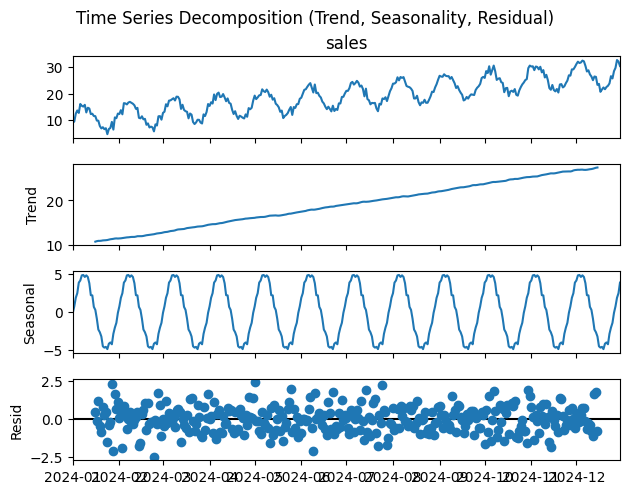

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


data = {
    "date": pd.date_range(start="2024-01-01", periods=365, freq="D"),
    "sales": (
        10 + 
        0.05 * pd.Series(range(365)) +  # trend
        5 * pd.Series(range(365)).apply(lambda x: __import__("numpy").sin(2 * __import__("numpy").pi * x / 30)) +  # seasonality
        __import__("numpy").random.normal(0, 1, 365)  # noise
    )
}

df = pd.DataFrame(data)
df.set_index("date", inplace=True)

# Decomposition (additive model)
result = seasonal_decompose(df["sales"], model="additive", period=30)

# Plot components
result.plot()
plt.suptitle("Time Series Decomposition (Trend, Seasonality, Residual)", y=1.02)
plt.show()


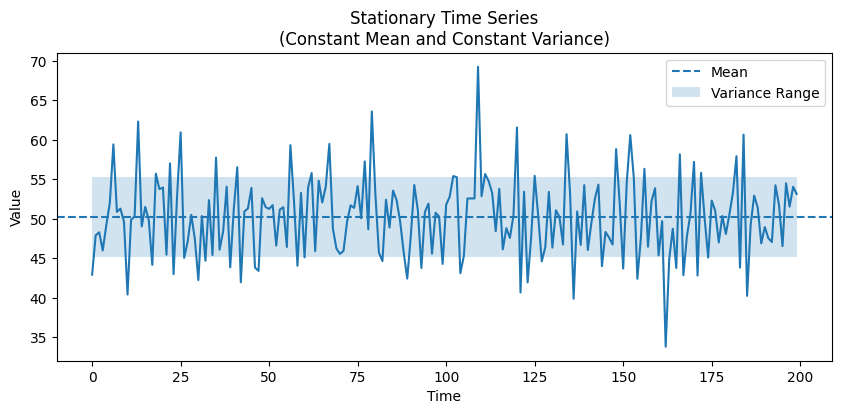

In [10]:
# Generate stationary data

n = 200

stationary = np.random.normal(
    loc=50,      # constant mean
    scale=5,     # constant variance
    size=n
)

# Plot

plt.figure(figsize=(10, 4))

plt.plot(stationary)

# Mean line
plt.axhline(
    y=np.mean(stationary),
    linestyle='--',
    label='Mean'
)

# Variance band
plt.fill_between(
    range(n),
    np.mean(stationary) - np.std(stationary),
    np.mean(stationary) + np.std(stationary),
    alpha=0.2,
    label='Variance Range'
)

plt.title(
    "Stationary Time Series\n(Constant Mean and Constant Variance)"
)

plt.xlabel("Time")
plt.ylabel("Value")

plt.legend()

plt.show()

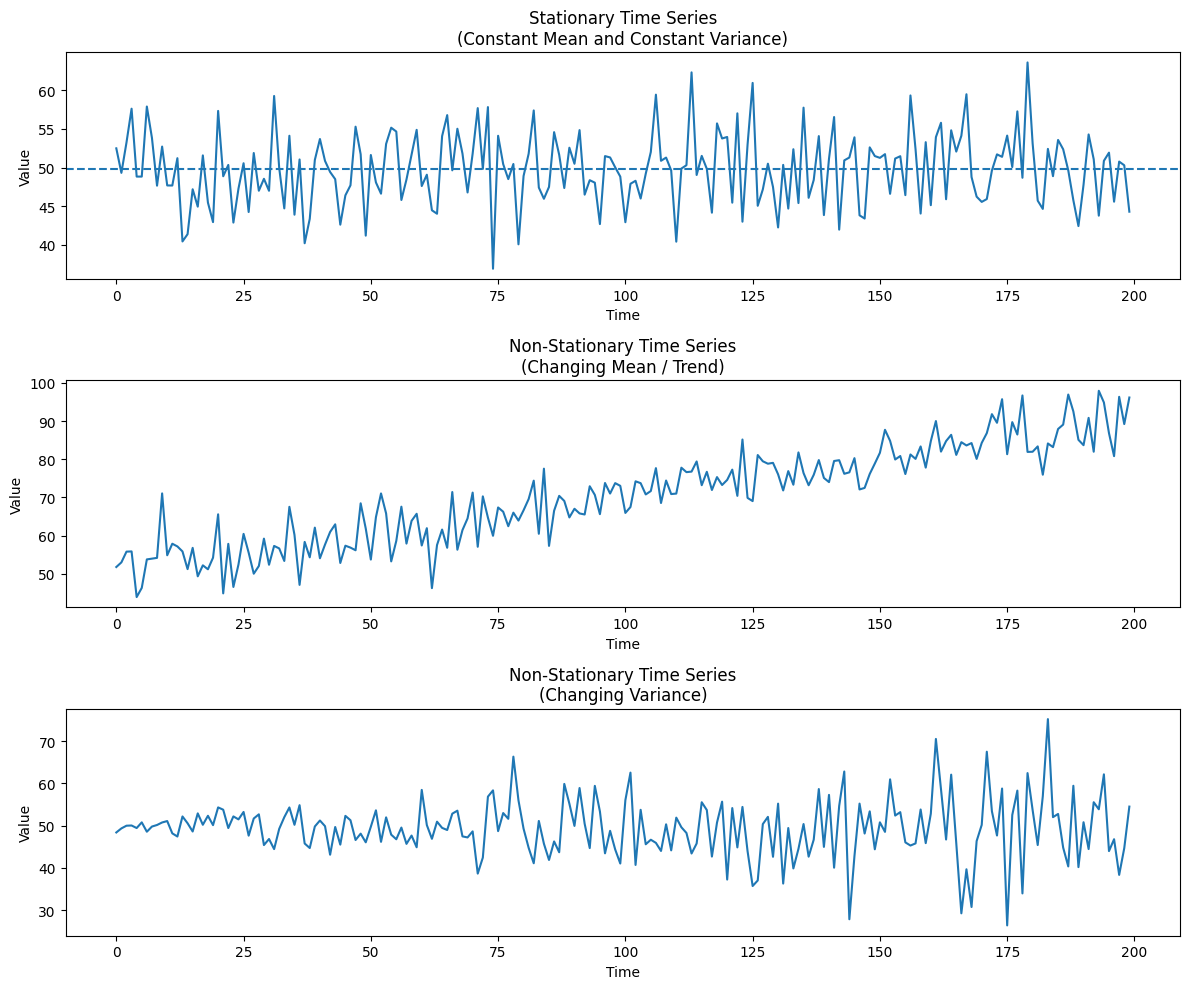

In [2]:
# ==========================================
# Stationarity: Mean and Variance Examples
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ------------------------------------------
# 1. Stationary Time Series
# Constant mean and constant variance
# ------------------------------------------

n = 200

stationary = np.random.normal(
    loc=50,      # constant mean
    scale=5,     # constant variance
    size=n
)

# ------------------------------------------
# 2. Non-Stationary Time Series (Changing Mean)
# Upward trend increases the mean over time
# ------------------------------------------

trend = np.linspace(0, 40, n)

non_stationary_mean = 50 + trend + np.random.normal(
    loc=0,
    scale=5,
    size=n
)

# ------------------------------------------
# 3. Non-Stationary Time Series (Changing Variance)
# Variance increases over time
# ------------------------------------------

changing_variance = 50 + np.random.normal(
    loc=0,
    scale=np.linspace(1, 12, n),   # increasing variance
    size=n
)

# ==========================================
# Plotting
# ==========================================

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# ------------------------------------------
# Plot 1: Stationary
# ------------------------------------------

axes[0].plot(stationary)

axes[0].axhline(
    y=np.mean(stationary),
    linestyle='--'
)

axes[0].set_title(
    "Stationary Time Series\n(Constant Mean and Constant Variance)"
)

axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")

# ------------------------------------------
# Plot 2: Non-Stationary (Changing Mean)
# ------------------------------------------

axes[1].plot(non_stationary_mean)

axes[1].set_title(
    "Non-Stationary Time Series\n(Changing Mean / Trend)"
)

axes[1].set_xlabel("Time")
axes[1].set_ylabel("Value")

# ------------------------------------------
# Plot 3: Non-Stationary (Changing Variance)
# ------------------------------------------

axes[2].plot(changing_variance)

axes[2].set_title(
    "Non-Stationary Time Series\n(Changing Variance)"
)

axes[2].set_xlabel("Time")
axes[2].set_ylabel("Value")

plt.tight_layout()
plt.show()

# Time Series Decomposition Models

## 1. Additive Model (Constant Seasonal Effect + Constant Increase)

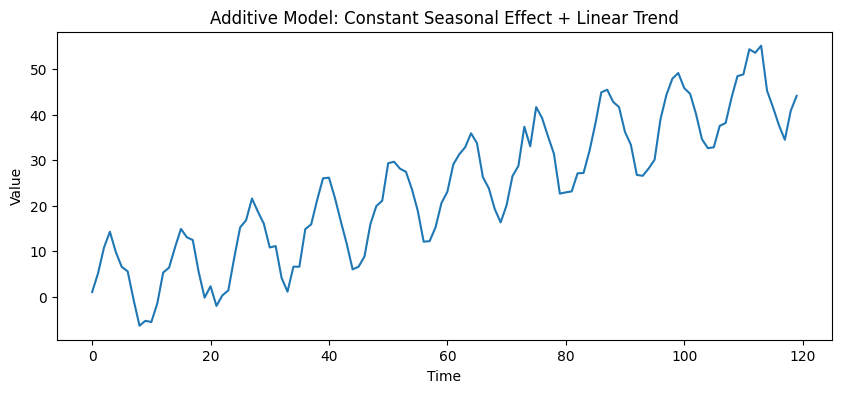

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

t = np.arange(0, 120)

# Constant linear increase (trend)
trend = 0.4 * t

# Constant seasonality (does NOT change with level)
seasonality = 10 * np.sin(2 * np.pi * t / 12)

# Noise
noise = np.random.normal(0, 2, len(t))

# Additive model
y_add = trend + seasonality + noise

plt.figure(figsize=(10,4))
plt.plot(y_add)

plt.title("Additive Model: Constant Seasonal Effect + Linear Trend")
plt.xlabel("Time")
plt.ylabel("Value")

plt.show()

## 2. Multiplicative Model (Seasonality Increases with Level)

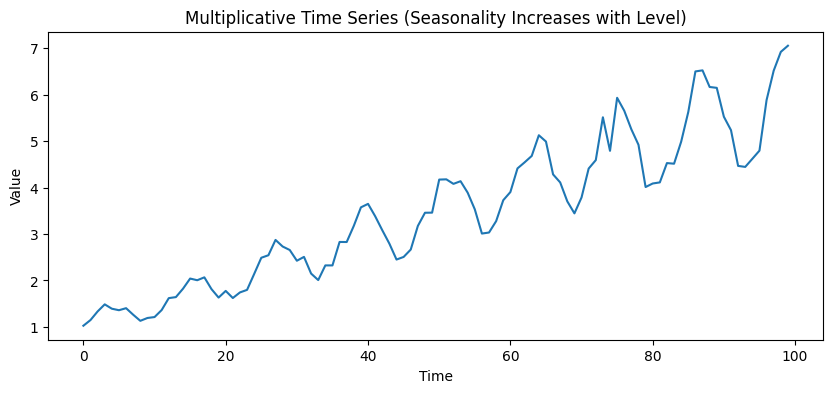

In [14]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

t = np.arange(0, 100)

# Trend
trend = 1 + 0.05 * t

# Seasonality (same pattern but scaled by trend)
seasonality = 1 + 0.2 * np.sin(2 * np.pi * t / 12)

# Noise
noise = np.random.normal(1, 0.05, 100)

# Multiplicative model
y_mul = trend * seasonality * noise

plt.figure(figsize=(10,4))
plt.plot(y_mul)
plt.title("Multiplicative Time Series (Seasonality Increases with Level)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# Visualization of Time Series

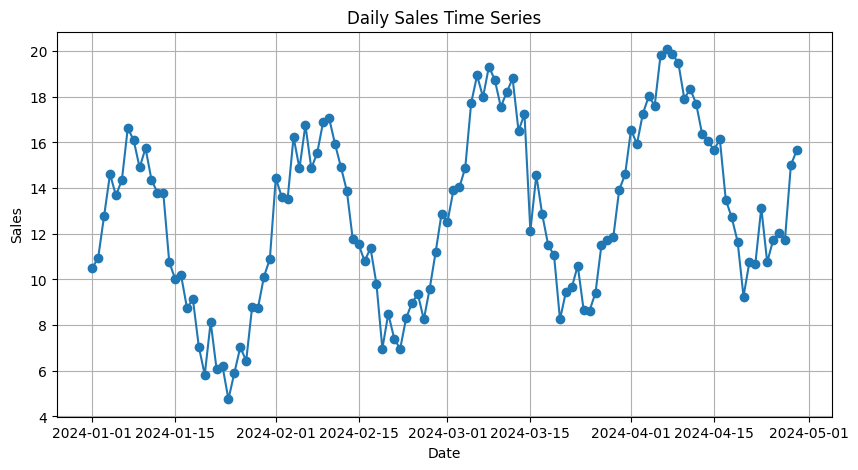

In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

np.random.seed(42)

data = {
    "date": pd.date_range(start="2024-01-01", periods=120, freq="D"),
    "sales": (
        10 +
        0.05 * pd.Series(range(120)) +
        5 * pd.Series(range(120)).apply(lambda x: np.sin(2 * np.pi * x / 30)) +
        np.random.normal(0, 1, 120)
    )
}

df = pd.DataFrame(data)
df.set_index("date", inplace=True)

plt.figure(figsize=(10,5))
plt.plot(df.index, df["sales"], marker='o')
plt.title("Daily Sales Time Series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()


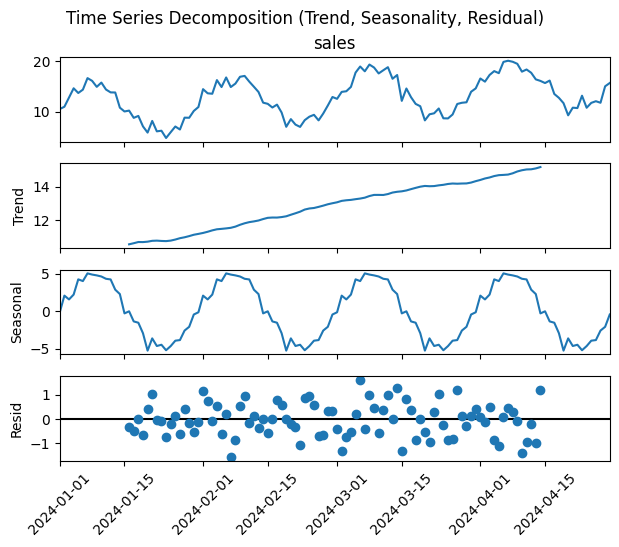

In [4]:
# Decomposition (additive model)
result = seasonal_decompose(df["sales"], model="additive", period=30)

# Plot components
result.plot()
plt.suptitle("Time Series Decomposition (Trend, Seasonality, Residual)", y=1.02)
plt.xticks(rotation=45)
plt.show()

## 2 Autocorrelation (ACF Analysis)

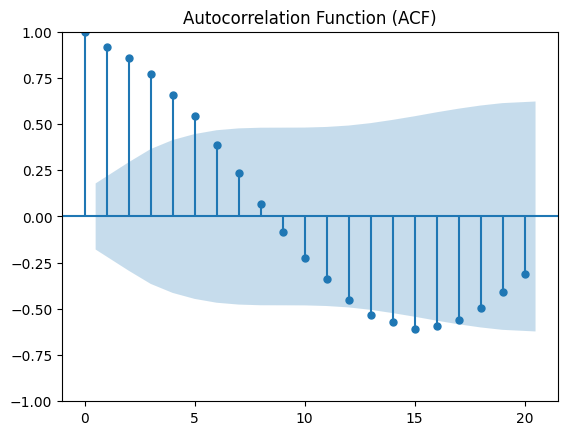

In [5]:

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df["sales"], lags=20)
plt.title("Autocorrelation Function (ACF)")
plt.show()


## 3 Differencing (Removing Trend)

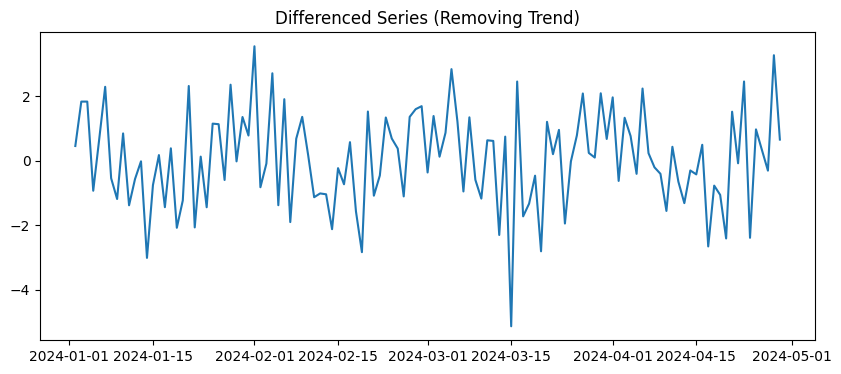

In [6]:

sales_diff = df["sales"].diff().dropna()

plt.figure(figsize=(10,4))
plt.plot(sales_diff)
plt.title("Differenced Series (Removing Trend)")
plt.show()


## 4. Autocorrelation After Differencing

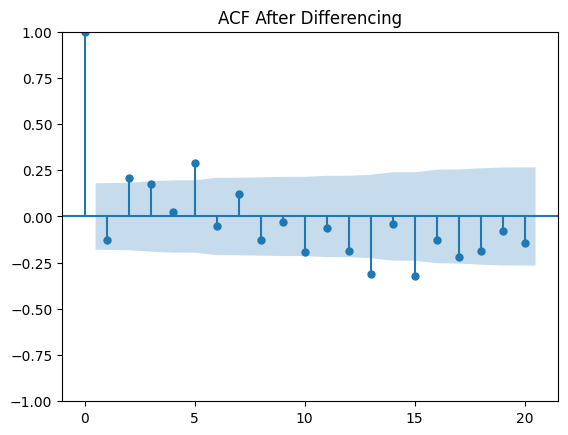

In [7]:

plot_acf(sales_diff, lags=20)
plt.title("ACF After Differencing")
plt.show()


## 5 Seasonal Temperature Data

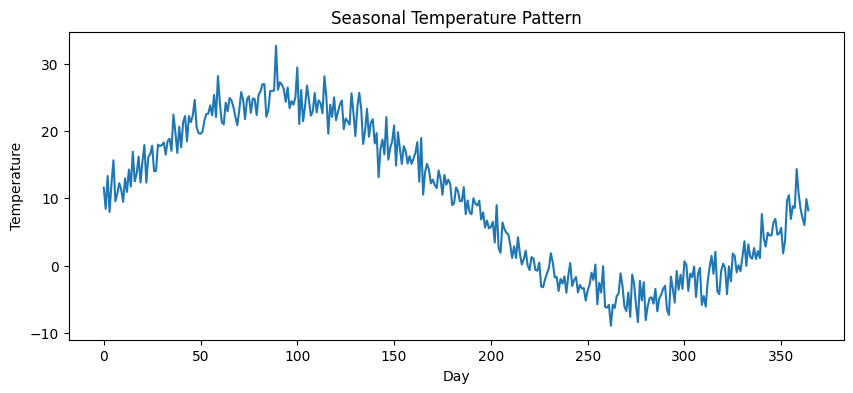

In [8]:

days = np.arange(365)
temperature = 10 + 15 * np.sin(2 * np.pi * days / 365) + np.random.normal(0, 2, 365)

plt.figure(figsize=(10,4))
plt.plot(days, temperature)
plt.title("Seasonal Temperature Pattern")
plt.xlabel("Day")
plt.ylabel("Temperature")
plt.show()


## 6. Random time series

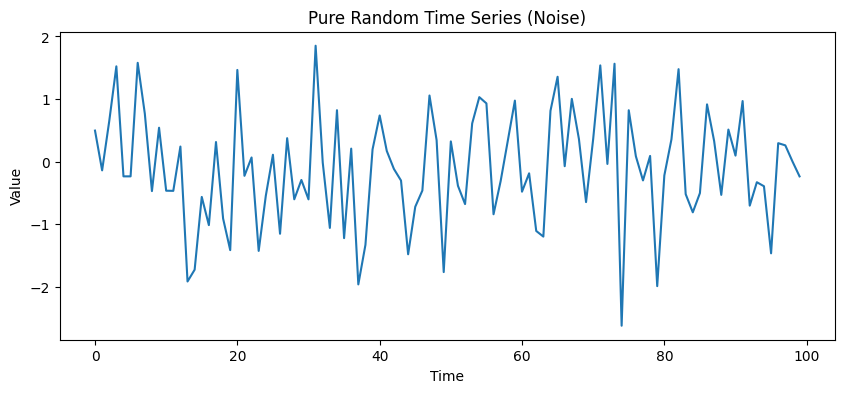

In [9]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

random_series = np.random.normal(0, 1, 100)

plt.figure(figsize=(10,4))
plt.plot(random_series)
plt.title("Pure Random Time Series (Noise)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

# This plot represents a purely random time series where values fluctuate without any visible structure.

Unlike earlier examples with trend or seasonality, this series:

has no upward or downward movement
shows no repeating pattern
cannot be predicted using past values

This type of data is often referred to as white noise and serves as an important baseline in time series analysis.